In [ ]:
!pip install pytorch-ignite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.7/312.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, roc_auc_score
from torchsummary import summary
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
import copy



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# **Задача 1**

Скачайте датасет Fashion MNIST, посмотрите на картинки, отделите валидационную выборку и обучите одну полносвязную архитектуру. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.7MB/s]


In [ ]:
pd.Series(train_dataset.targets).value_counts() #чекнула на дисбаланс

,count
9,6000
0,6000
3,6000
2,6000
7,6000
5,6000
1,6000
6,6000
4,6000
8,6000


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

labels = train_dataset.targets.numpy()

train_indices, val_indices = train_test_split(
    range(len(train_dataset)), #индексы
    test_size=0.2,
    stratify=labels,
)#хочу не просто разделить как-то а имено от каждого класса по равному количесву

train_data = Subset(train_dataset, train_indices)
val_data = Subset(train_dataset, val_indices)


In [ ]:
image, _ = train_dataset[0]
image.shape

torch.Size([1, 28, 28])

In [ ]:
pd.Series([train_data[i][1] for i in range(len(train_data))]).value_counts()#проверила

,count
7,4800
3,4800
4,4800
1,4800
8,4800
9,4800
2,4800
6,4800
5,4800
0,4800


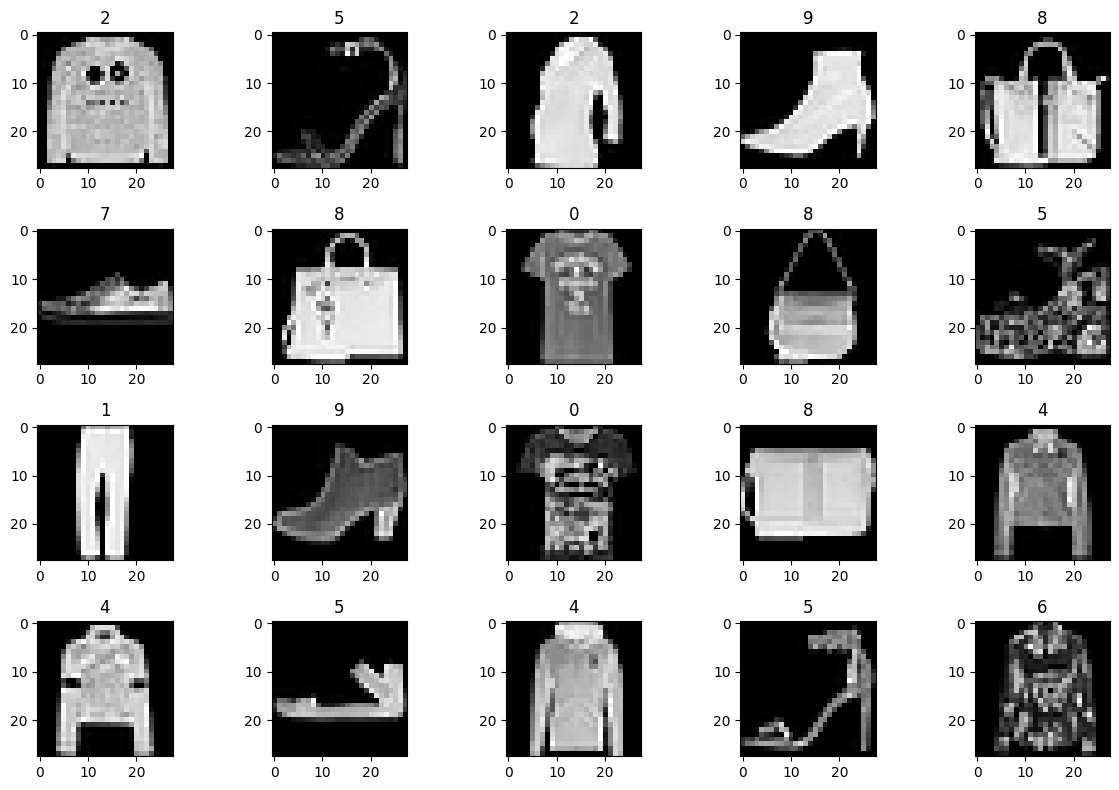

In [ ]:
plt.figure(figsize=(12,8))

for i in range(20):
    x, y = train_data[i]
    plt.subplot(4, 5, i + 1)
    plt.title(f'{y}')
    plt.imshow(x.squeeze(), cmap='gray')

plt.tight_layout()
plt.show()

In [ ]:
batch_size=64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
labels = train_dataset.targets
torch.unique(labels)#количество классов

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.flatten = nn.Flatten()       # разворачиваю в вектор
        self.fc1 = nn.Linear(28 * 28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)

        x = self.dropout1(self.relu1(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.fc2(x))))

        x = self.fc3(x)
        return x

model = Net().to(device)

summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
       BatchNorm1d-3                  [-1, 128]             256
              ReLU-4                  [-1, 128]               0
           Dropout-5                  [-1, 128]               0
            Linear-6                   [-1, 64]           8,256
       BatchNorm1d-7                   [-1, 64]             128
              ReLU-8                   [-1, 64]               0
           Dropout-9                   [-1, 64]               0
           Linear-10                   [-1, 10]             650
Total params: 109,770
Trainable params: 109,770
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.42
Estimated T

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer1 = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
from ignite.engine import create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss
from ignite.engine import Events
from ignite.handlers.param_scheduler import ReduceLROnPlateauScheduler
from ignite.handlers import EarlyStopping, ModelCheckpoint
import os

In [ ]:
#сделала функцию тк надо будет 4 раза запускать а так будет меньше кода

def train_and_evaluate(model, train_loader, val_loader, optimizer, criterion,model_name, device, max_epochs=50):
  model.to(device)

  save_dir = "best_models"#создала папку в которую буду сохранять веса лучших моделей по одной на модель
  os.makedirs(save_dir, exist_ok=True)

  metrics = {
    "accuracy": Accuracy(),
    "loss": Loss(criterion)
  }

  train_losses, val_losses = [], []
  train_accs, val_accs = [], []

  def log_metrics(engine):
      train_evaluator.run(train_loader)
      val_evaluator.run(val_loader)

      train_loss, train_acc = train_evaluator.state.metrics['loss'], train_evaluator.state.metrics['accuracy']
      val_loss, val_acc = val_evaluator.state.metrics['loss'], val_evaluator.state.metrics['accuracy']

      train_losses.append(train_loss)
      train_accs.append(train_acc)
      val_losses.append(val_loss)
      val_accs.append(val_acc)

      print(f"Epoch {engine.state.epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")
#буду выводить после каждой эпохи и полезно и когда долго ждешь не так мучительно ждать

  trainer = create_supervised_trainer(model, optimizer, criterion, device)

  train_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)
  val_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)

  trainer.add_event_handler(Events.EPOCH_COMPLETED, log_metrics)

  checkpoint = ModelCheckpoint(
    dirname=save_dir,
    filename_prefix=model_name,
    n_saved=1,
    score_function=lambda e: e.state.metrics["accuracy"],
    require_empty=False
  )#вооот тут идет сохранение лучшей модели

  val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, checkpoint, {"model": model})#лучшую выбираю по валидации


  early_stopping = EarlyStopping(
    patience=5,
    score_function=lambda e: e.state.metrics['accuracy'],
    trainer=trainer
    )#раняя остановка чтобы не ждать все эпохи

  val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, early_stopping)# так же по валидации сравниваю


  trainer.run(train_loader, max_epochs)

  best_model_path = checkpoint.last_checkpoint#вот тут уже путь созраняю тк модель сохраняется с акураси в названии пробовала это убрать но всегда приписывает акураси

  return train_losses, val_losses, train_accs, val_accs, best_model_path

In [ ]:
def plot_metrics(train_losses, val_losses, train_accs, val_accs):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()
#тоже функция тк вызываем в каждом задании

In [ ]:
train_losses_1, val_losses_1, train_accs_1, val_accs_1, best_model_path_1 = train_and_evaluate(
    model, train_loader, val_loader, optimizer1, criterion, 'Net', device
)

Epoch 1: Train Loss = 0.4219, Val Loss = 0.4181, Train Acc = 0.8468, Val Acc = 0.8448
Epoch 2: Train Loss = 0.3856, Val Loss = 0.3879, Train Acc = 0.8596, Val Acc = 0.8578
Epoch 3: Train Loss = 0.3808, Val Loss = 0.3841, Train Acc = 0.8603, Val Acc = 0.8563
Epoch 4: Train Loss = 0.3538, Val Loss = 0.3652, Train Acc = 0.8695, Val Acc = 0.8669
Epoch 5: Train Loss = 0.3443, Val Loss = 0.3612, Train Acc = 0.8726, Val Acc = 0.8660
Epoch 6: Train Loss = 0.3316, Val Loss = 0.3492, Train Acc = 0.8762, Val Acc = 0.8688
Epoch 7: Train Loss = 0.3276, Val Loss = 0.3451, Train Acc = 0.8803, Val Acc = 0.8721
Epoch 8: Train Loss = 0.3307, Val Loss = 0.3514, Train Acc = 0.8793, Val Acc = 0.8707
Epoch 9: Train Loss = 0.3042, Val Loss = 0.3265, Train Acc = 0.8881, Val Acc = 0.8797
Epoch 10: Train Loss = 0.3206, Val Loss = 0.3455, Train Acc = 0.8751, Val Acc = 0.8702
Epoch 11: Train Loss = 0.3078, Val Loss = 0.3356, Train Acc = 0.8829, Val Acc = 0.8730
Epoch 12: Train Loss = 0.2943, Val Loss = 0.3281, Tr

2025-03-25 15:15:11,280 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Epoch 14: Train Loss = 0.2891, Val Loss = 0.3263, Train Acc = 0.8917, Val Acc = 0.8784


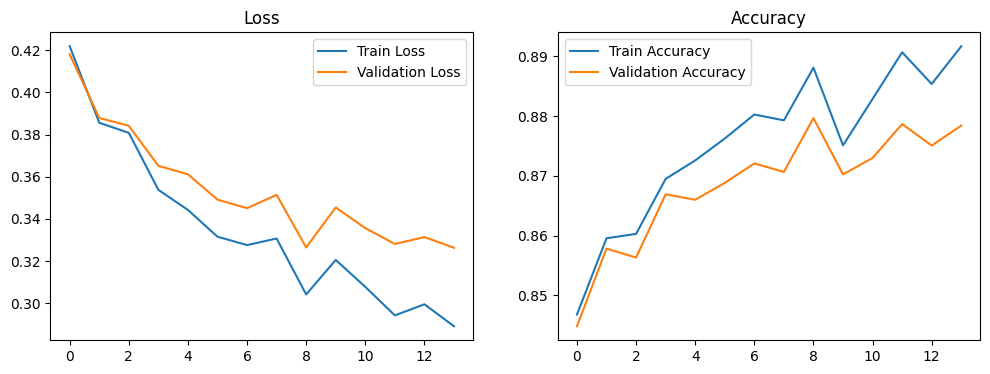

In [ ]:
plot_metrics(train_losses_1, val_losses_1, train_accs_1, val_accs_1)
#видим что уменьшаетяс может быть если пообучать подольше(поставить ранюю остановку чуть побольше) то выйдем на явное плато, но пока что ошибка уменьшается

In [ ]:
def plot_roc(model, model_name, val_loader, device):
    model.eval()
    val_preds, val_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch.to(device))
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            val_preds.extend(probs)
            val_targets.extend(y_batch.cpu().numpy())

    val_preds = np.array(val_preds)
    val_targets = np.array(val_targets)

    fpr, tpr, roc_auc = {}, {}, {}
    n_classes = val_preds.shape[1]

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(val_targets == i, val_preds[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves for {model_name}')
    plt.legend(loc='lower right')
    plt.show()

#мне просто интересно какой класс хуже всего отличается, ради эксперемента и далее буду чекать вдруг что-то интересное будет

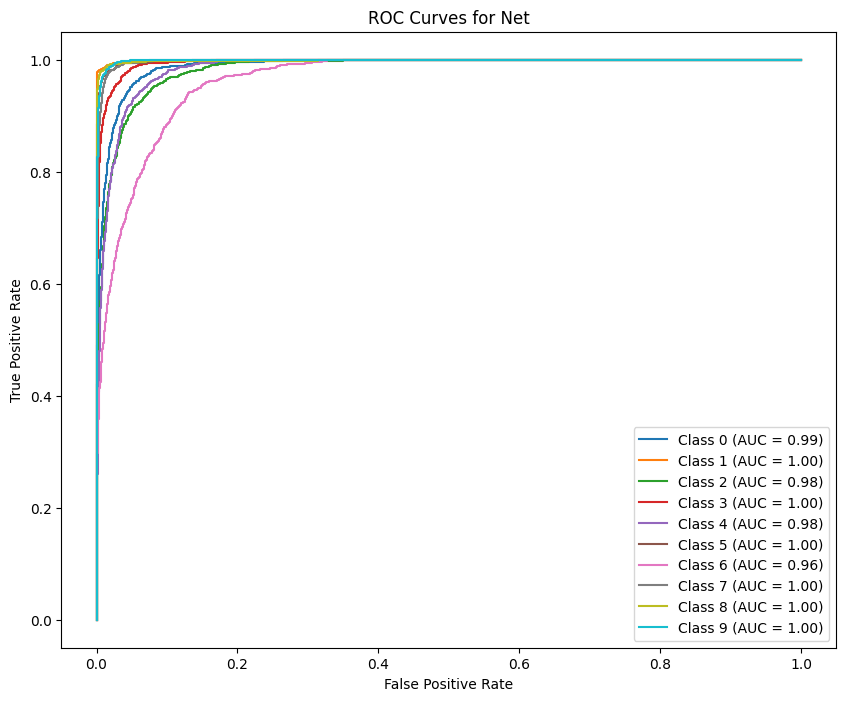

In [ ]:
model.load_state_dict(torch.load(best_model_path_1))
plot_roc(model, 'Net', val_loader, device)#название на самом деле не нужно но я так отслеживаю не запуталась ли то что вывожу

# **Задача 2**

Добавьте в архитектуру свёртки. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [ ]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.relu4 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.dropout1(self.relu3(self.bn3(self.fc1(x))))
        x = self.dropout2(self.relu4(self.bn4(self.fc2(x))))
        x = self.fc3(x)
        return x

model_conv = ConvNet().to(device)
summary(model_conv, (1,28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
            Conv2d-5           [-1, 64, 14, 14]          18,496
       BatchNorm2d-6           [-1, 64, 14, 14]             128
              ReLU-7           [-1, 64, 14, 14]               0
         MaxPool2d-8             [-1, 64, 7, 7]               0
           Flatten-9                 [-1, 3136]               0
           Linear-10                  [-1, 128]         401,536
      BatchNorm1d-11                  [-1, 128]             256
             ReLU-12                  [-1, 128]               0
          Dropout-13                  [-1, 128]               0
           Linear-14                   

In [ ]:
optimizer2 = optim.Adam(model_conv.parameters(), lr=0.01)#переопределяю тк модель другая

In [ ]:
train_losses_2, val_losses_2, train_accs_2, val_accs_2, best_model_path_2 = train_and_evaluate(
    model_conv, train_loader, val_loader, optimizer2, criterion, 'Conv', device
)

Epoch 1: Train Loss = 0.3255, Val Loss = 0.3239, Train Acc = 0.8829, Val Acc = 0.8812
Epoch 2: Train Loss = 0.2518, Val Loss = 0.2563, Train Acc = 0.9073, Val Acc = 0.9056
Epoch 3: Train Loss = 0.2279, Val Loss = 0.2440, Train Acc = 0.9174, Val Acc = 0.9081
Epoch 4: Train Loss = 0.1959, Val Loss = 0.2206, Train Acc = 0.9253, Val Acc = 0.9169
Epoch 5: Train Loss = 0.1854, Val Loss = 0.2191, Train Acc = 0.9305, Val Acc = 0.9185
Epoch 6: Train Loss = 0.1683, Val Loss = 0.2077, Train Acc = 0.9402, Val Acc = 0.9235
Epoch 7: Train Loss = 0.1764, Val Loss = 0.2147, Train Acc = 0.9349, Val Acc = 0.9219
Epoch 8: Train Loss = 0.1654, Val Loss = 0.2163, Train Acc = 0.9392, Val Acc = 0.9213
Epoch 9: Train Loss = 0.1509, Val Loss = 0.2019, Train Acc = 0.9437, Val Acc = 0.9243
Epoch 10: Train Loss = 0.1601, Val Loss = 0.2213, Train Acc = 0.9363, Val Acc = 0.9162
Epoch 11: Train Loss = 0.1270, Val Loss = 0.1952, Train Acc = 0.9529, Val Acc = 0.9305
Epoch 12: Train Loss = 0.1318, Val Loss = 0.2019, Tr

2025-03-25 15:21:54,732 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Epoch 16: Train Loss = 0.1104, Val Loss = 0.2084, Train Acc = 0.9570, Val Acc = 0.9253


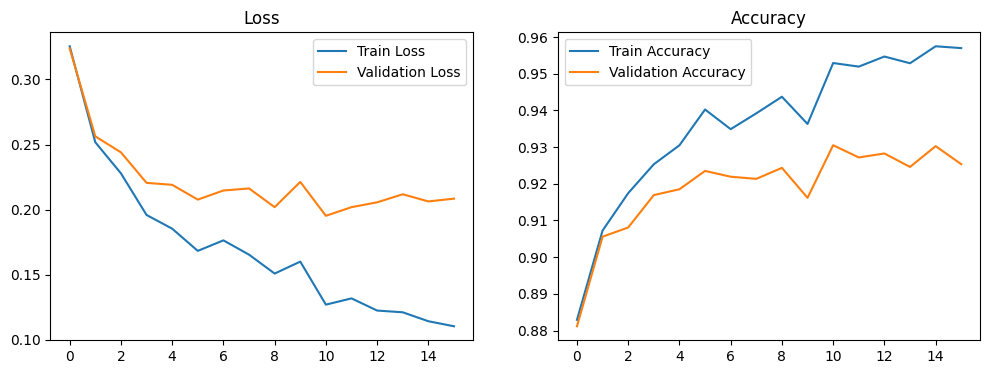

In [ ]:
plot_metrics(train_losses_2, val_losses_2, train_accs_2, val_accs_2)
#вот тут обучение пошло побыстрее и точность стала побольше, видно чо свертки лучше работают с изображениями чем просто лин. модель,
#но к сожалению вышли на что-то похожее на плато на валидации
#похоже больше по точности выжать будет трудно да и ошибка между валидацией и трейном уже большая, вероятно просто дальше перееобучение будет

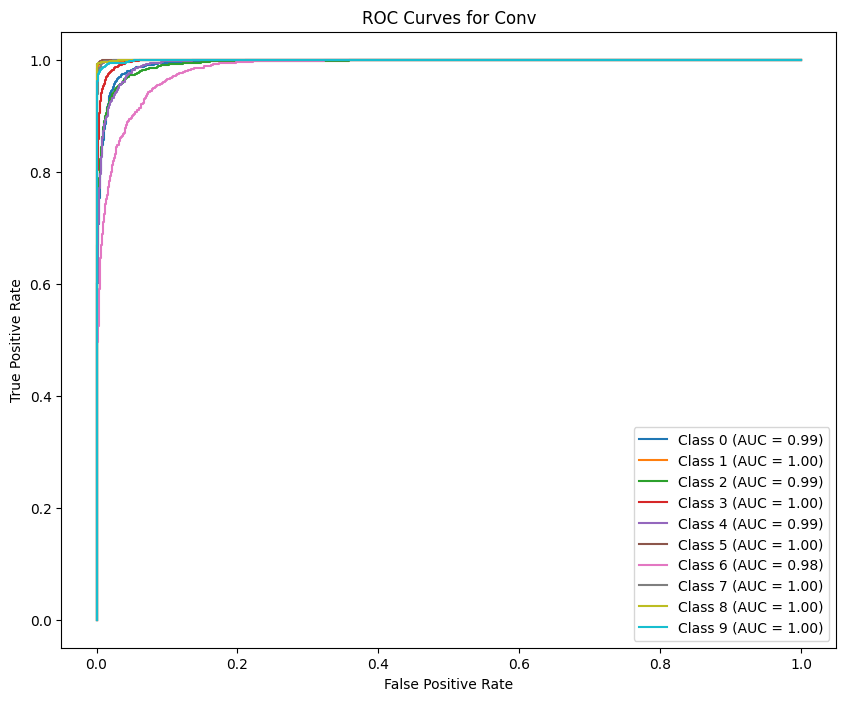

In [ ]:
model_conv.load_state_dict(torch.load(best_model_path_2))
plot_roc(model_conv, 'Conv', val_loader, device)#вижим что 6 класс стал лучше определяться

# **Задача 3**

Добавьте аугментации в трейновый датасет, посмотрите на картинки. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

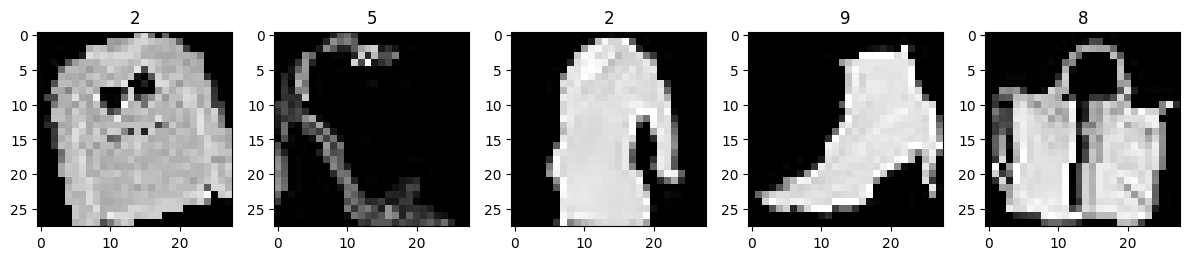

In [ ]:
from torchvision.transforms import RandomHorizontalFlip, RandomRotation

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),#еще решида поворот небольшой добавить
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


train_dataset_aug = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)
train_data_aug = Subset(train_dataset_aug, train_indices)#  я индексы уже ранее разделяла, сделал атак чтобы не совсем тупо делить а не создавать дисбаланс искуственно

train_loader_aug = DataLoader(
    train_data_aug,
    batch_size=batch_size,
    shuffle=True
)

plt.figure(figsize=(12,8))
for i in range(5):
    x, y = train_data_aug[i]
    plt.subplot(1, 5, i + 1)
    plt.title(f'{y}')
    plt.imshow(x.squeeze(), cmap='gray')

plt.tight_layout()
plt.show()

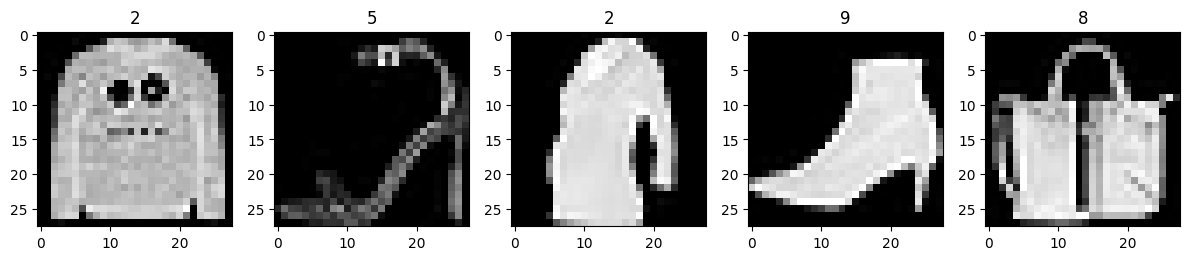

In [ ]:
plt.figure(figsize=(12,8))
for i in range(5):
    x, y = train_data[i]
    plt.subplot(1, 5, i + 1)
    plt.title(f'{y}')
    plt.imshow(x.squeeze(), cmap='gray')

plt.tight_layout()
plt.show()#тут для сравнения не отзеркаленые и не повернутые

In [ ]:
model_conv_aug = ConvNet().to(device)
optimizer3 = optim.Adam(model_conv_aug.parameters(), lr=0.01)

In [ ]:
train_losses_3, val_losses_3, train_accs_3, val_accs_3, best_model_path_3 = train_and_evaluate(
    model_conv_aug, train_loader_aug, val_loader, optimizer3, criterion, 'Conv_Aug', device
)

Epoch 1: Train Loss = 0.4058, Val Loss = 0.3699, Train Acc = 0.8497, Val Acc = 0.8634
Epoch 2: Train Loss = 0.3543, Val Loss = 0.3257, Train Acc = 0.8701, Val Acc = 0.8803
Epoch 3: Train Loss = 0.3346, Val Loss = 0.3125, Train Acc = 0.8705, Val Acc = 0.8780
Epoch 4: Train Loss = 0.2953, Val Loss = 0.2742, Train Acc = 0.8908, Val Acc = 0.8967
Epoch 5: Train Loss = 0.3003, Val Loss = 0.2748, Train Acc = 0.8854, Val Acc = 0.8953
Epoch 6: Train Loss = 0.3313, Val Loss = 0.3065, Train Acc = 0.8713, Val Acc = 0.8843
Epoch 7: Train Loss = 0.2681, Val Loss = 0.2541, Train Acc = 0.8984, Val Acc = 0.9038
Epoch 8: Train Loss = 0.2595, Val Loss = 0.2406, Train Acc = 0.9066, Val Acc = 0.9117
Epoch 9: Train Loss = 0.2561, Val Loss = 0.2406, Train Acc = 0.9035, Val Acc = 0.9093
Epoch 10: Train Loss = 0.2590, Val Loss = 0.2510, Train Acc = 0.9021, Val Acc = 0.9052
Epoch 11: Train Loss = 0.2508, Val Loss = 0.2372, Train Acc = 0.9044, Val Acc = 0.9099
Epoch 12: Train Loss = 0.2422, Val Loss = 0.2341, Tr

2025-03-25 15:39:43,307 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Epoch 29: Train Loss = 0.1975, Val Loss = 0.2084, Train Acc = 0.9270, Val Acc = 0.9254


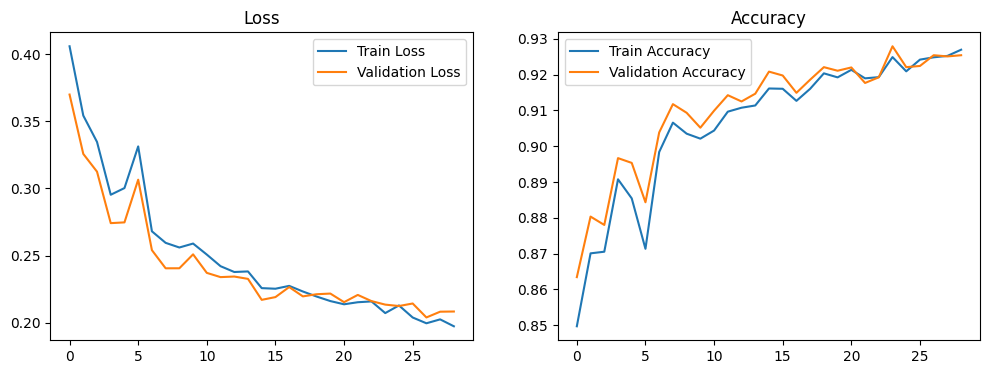

In [ ]:
plot_metrics(train_losses_3, val_losses_3, train_accs_3, val_accs_3)
#мне очень нравится результат, видно, что трейн и валидация равномерно уменьшаются, как будто вот тут хорошо бы просто побольше эпох поставить

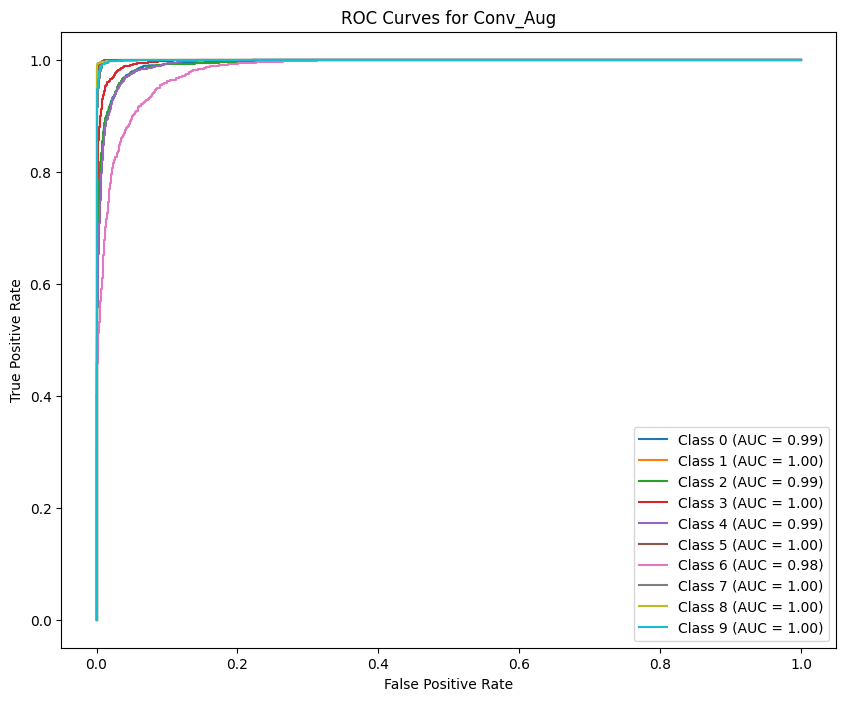

In [ ]:
model_conv.load_state_dict(torch.load(best_model_path_3))
plot_roc(model_conv, 'Conv_Aug', val_loader, device)

# **Задача 4**

Добавьте skip-connection. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

In [ ]:
class ConvNetWithSkip(nn.Module):
    def __init__(self, base_model):
        super(ConvNetWithSkip, self).__init__()

        self.base_model = base_model #берем прошлую модель из задания 2 и просто связи через слои настроим

        self.skip_convs = nn.ModuleList([
            nn.Conv2d(1, 32, kernel_size=1, stride=2),   # между 1 и 2 сверточным
            nn.Conv2d(32, 64, kernel_size=1, stride=2),  # между 2 и 3
            nn.Conv2d(1, 64, kernel_size=1, stride=4) #не знаю хорошая ли идея но решила и между 1 и 3 попробовать
        ])

    def forward(self, x):

        skip1 = self.skip_convs[0](x)
        skip13=self.skip_convs[2](x)#вот этв немного эксперементальная связь
        x = self.base_model.pool1(self.base_model.relu1(self.base_model.bn1(self.base_model.conv1(x))))
        x += skip1

        skip2 = self.skip_convs[1](x)
        x = self.base_model.pool2(self.base_model.relu2(self.base_model.bn2(self.base_model.conv2(x))))
        x = x + skip2+skip13

        x = self.base_model.flatten(x)
        x = self.base_model.dropout1(self.base_model.relu3(self.base_model.bn3(self.base_model.fc1(x))))
        x = self.base_model.dropout2(self.base_model.relu4(self.base_model.bn4(self.base_model.fc2(x))))
        x = self.base_model.fc3(x)
        return x

model_conv_base = ConvNet().to(device)
model_skip = ConvNetWithSkip(model_conv_base).to(device)
summary(model_skip, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 14, 14]              64
            Conv2d-2             [-1, 64, 7, 7]             128
            Conv2d-3           [-1, 32, 28, 28]             320
       BatchNorm2d-4           [-1, 32, 28, 28]              64
              ReLU-5           [-1, 32, 28, 28]               0
         MaxPool2d-6           [-1, 32, 14, 14]               0
            Conv2d-7             [-1, 64, 7, 7]           2,112
            Conv2d-8           [-1, 64, 14, 14]          18,496
       BatchNorm2d-9           [-1, 64, 14, 14]             128
             ReLU-10           [-1, 64, 14, 14]               0
        MaxPool2d-11             [-1, 64, 7, 7]               0
          Flatten-12                 [-1, 3136]               0
           Linear-13                  [-1, 128]         401,536
      BatchNorm1d-14                  [

In [ ]:
optimizer4 = optim.Adam(model_skip.parameters(), lr=0.01)

In [ ]:
train_losses_4, val_losses_4, train_accs_4, val_accs_4, best_model_path_4 = train_and_evaluate(
    model_skip, train_loader_aug, val_loader, optimizer4, criterion, 'Conv_Skip', device
)

Epoch 1: Train Loss = 0.4417, Val Loss = 0.4005, Train Acc = 0.8329, Val Acc = 0.8482
Epoch 2: Train Loss = 0.3536, Val Loss = 0.3350, Train Acc = 0.8661, Val Acc = 0.8729
Epoch 3: Train Loss = 0.3295, Val Loss = 0.3153, Train Acc = 0.8784, Val Acc = 0.8822
Epoch 4: Train Loss = 0.3120, Val Loss = 0.3023, Train Acc = 0.8809, Val Acc = 0.8839
Epoch 5: Train Loss = 0.3154, Val Loss = 0.3144, Train Acc = 0.8813, Val Acc = 0.8836
Epoch 6: Train Loss = 0.3046, Val Loss = 0.3008, Train Acc = 0.8868, Val Acc = 0.8867
Epoch 7: Train Loss = 0.2824, Val Loss = 0.2756, Train Acc = 0.8943, Val Acc = 0.8978
Epoch 8: Train Loss = 0.2679, Val Loss = 0.2625, Train Acc = 0.9010, Val Acc = 0.9032
Epoch 9: Train Loss = 0.2597, Val Loss = 0.2599, Train Acc = 0.9040, Val Acc = 0.9042
Epoch 10: Train Loss = 0.2863, Val Loss = 0.2917, Train Acc = 0.8960, Val Acc = 0.8958
Epoch 11: Train Loss = 0.2604, Val Loss = 0.2640, Train Acc = 0.9032, Val Acc = 0.9038
Epoch 12: Train Loss = 0.2573, Val Loss = 0.2595, Tr

2025-03-25 19:48:20,775 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Epoch 22: Train Loss = 0.2249, Val Loss = 0.2434, Train Acc = 0.9151, Val Acc = 0.9113


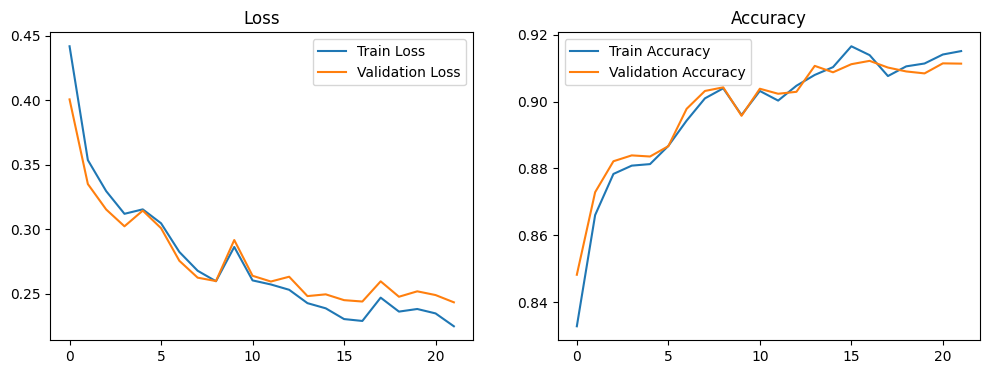

In [ ]:
plot_metrics(train_losses_4, val_losses_4, train_accs_4, val_accs_4)
#хмм интересно но график какойто более гладкий чтоли получился, правдв точность чуть пониже, но думаю на тяжелых моделях это будет выйгрышная стратегия

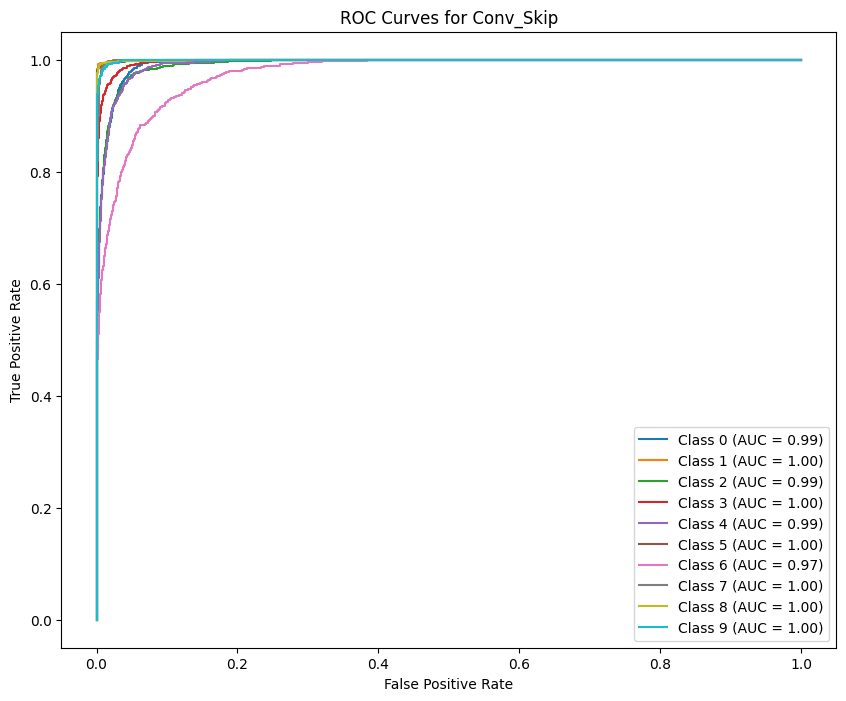

In [ ]:
model_skip.load_state_dict(torch.load(best_model_path_4))
plot_roc(model_skip, 'Conv_Skip', val_loader, device)

Вообще стоит заметить что во всех моделях 6 класс определялся хуже всего.
По метрикам лучше всего работал вариант из 2 задания без аугментации, но (по мне) с ней модель имеет шанс обучиться лучше, если например ее на больше количесво эпох запустить и поменять ранюю остановку на число побольше, а вот сверточная модель без аугментации уже в нашем эксперементе вышла на максимум.
вот модель из 4 задания для нашего датасета избыточна (по моему мнению), но механизм интересный. линейная модель вроде неплохо справилась но долго выжимается результат, хотя шаг приличный, это как раз показывает, что свертки все таки с изображениями лучше работают.

Accuracy max на валидации:

1)0.8797

2)0.9305

3)0.9279

4)0.9122